In [14]:
import pandas 
import numpy as np
import moments 
import dpluspy 
import scipy
import demesdraw
import demes

In [9]:
import matplotlib, matplotlib.pylab as plt

plt.rcParams["legend.title_fontsize"] = "small"
matplotlib.rc("xtick", labelsize=8)
matplotlib.rc("ytick", labelsize=8)
matplotlib.rc("axes", labelsize=8)
matplotlib.rc("axes", titlesize=8)
matplotlib.rc("legend", fontsize=8)
plt.rcParams['legend.title_fontsize'] = 'small'

In [10]:
# Load best-fit models and data

u = 1.3e-8

graph_0 = "results/model_0_rep4.yaml"
graph_1 = "results/model_1_rep1.yaml"
graph_2 = "results/model_2_rep1.yaml"

params_0 = "models/model_0_params.yaml"
params_1 = "models/model_1_params.yaml"
params_2 = "models/model_2_params.yaml"

data_file = "../../../../analyses/recombination_maps/stats/subset_Bherer.pkl"

data = dpluspy.inference.load_bootstrap_reps(
    data_file, graph=graph_0, return_dict=True)

model_0 = dpluspy.inference.compute_bin_stats(graph_0, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
model_1 = dpluspy.inference.compute_bin_stats(graph_1, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
model_2 = dpluspy.inference.compute_bin_stats(graph_2, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)

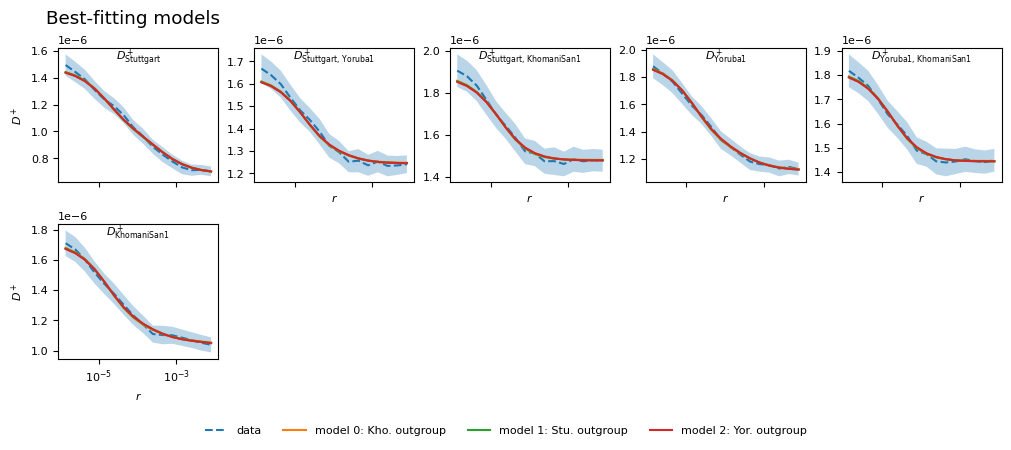

In [11]:
dpluspy.plotting.plot_D_plus_curves(
    models=[model_0, model_1, model_2],
    pop_ids=data["pop_ids"], 
    bins=data["bins"], 
    means=data["means"], 
    varcovs=data["varcovs"], 
    labels=["data", "model 0: Kho. outgroup", "model 1: Stu. outgroup",
            "model 2: Yor. outgroup"],
    title="Best-fitting models",
    out="figures/best_fits.pdf"
)

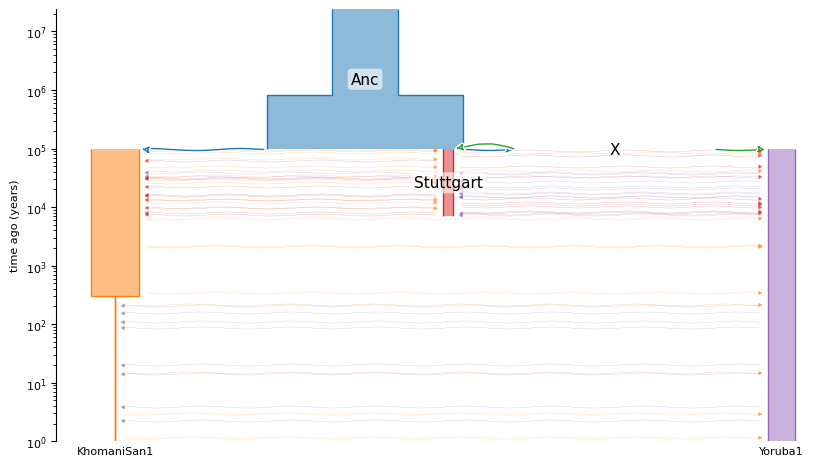

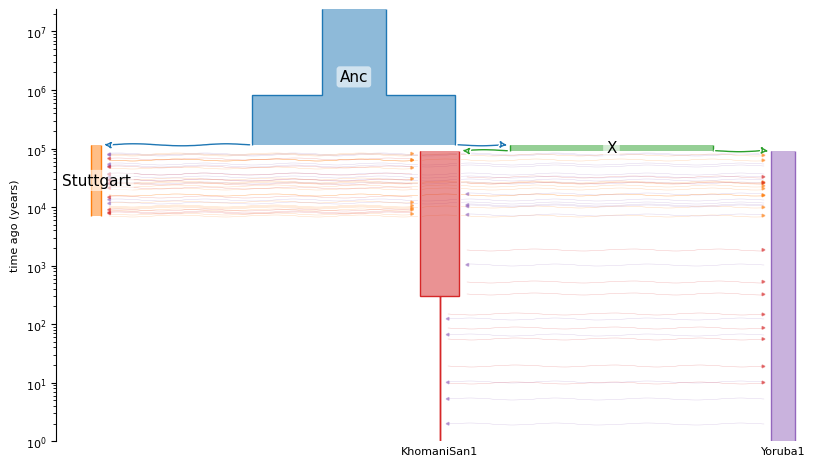

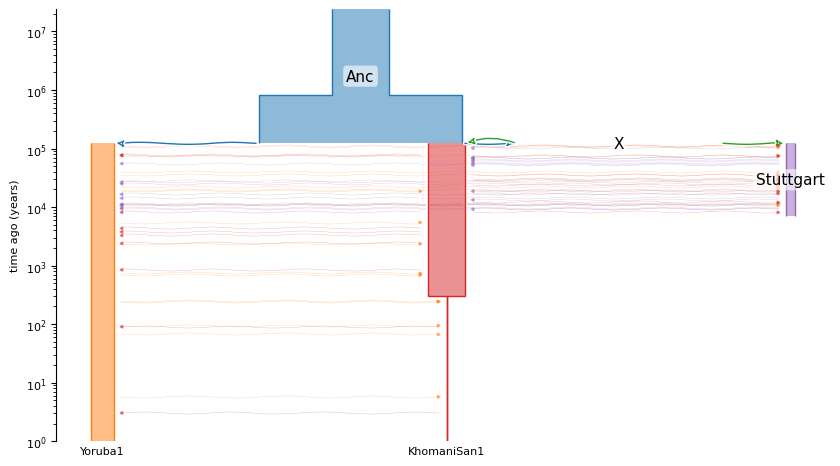

In [17]:
demesdraw.tubes(demes.load(graph_0), log_time=True)
plt.savefig("figures/graph_model_0_best_fit.pdf")

demesdraw.tubes(demes.load(graph_1), log_time=True)
plt.savefig("figures/graph_model_1_best_fit.pdf")

demesdraw.tubes(demes.load(graph_2), log_time=True)
plt.savefig("figures/graph_model_2_best_fit.pdf")